# CV-IPCW-HAL-MLE for Right-Censored Data

This notebook demonstrates **cross-validated IPCW-HAL density estimation** for right-censored data on [0,1].

## Problem Setup

For right-censored data we observe `(T, Δ)` where:
- `T = min(X, C)` — observed time (minimum of true event time and censoring time)
- `Δ = I(X ≤ C)` — event indicator (1 if observed, 0 if censored)

## Method Overview

| Component | Description |
|-----------|-------------|
| **Kaplan-Meier** | Estimates censoring survival function S_c(t) |
| **IPCW Weights** | Inverse probability of censoring weights |
| **HAL-MLE** | Highly Adaptive Lasso density estimator |
| **CV Tuning** | Cross-validation for `basis_order` and `norm_constraint` |

## Notebook Outline

1. **Data Simulation** — Generate right-censored truncated GMM data
2. **Kaplan-Meier** — Estimate censoring survival function
3. **IPCW-HAL Baseline** — Fit initial weighted HAL estimate (manual params)
4. **CV-IPCW-HAL Tuning** — Cross-validated hyperparameter optimization
5. **Evaluation** — Compare methods against true density


In [1]:
# Imports
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from haldensity.utils import (
    TruncatedNormal,
    TruncatedGMM,
    Sinusoidal,
    StepFunction
)

from haldensity.censoring import (
    # Utilities
    KaplanMeier,
    compute_ipcw_weights,
    # Estimators
    RightCensoredIPCWEstimator,
    # Tuners
    RightCensoredOptunaHyperparameterTuner,
    # Metrics
    kl_divergence,
    incomplete_loglik,
)

print("✓ Imports successful")


/Users/houyilong/Documents/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports successful


## 1. Data Simulation

Generate right-censored data from a **truncated Gaussian Mixture Model** on [0,1]:
- True event times: `X ~ TruncatedGMM` (3 components)
- Censoring times: `C ~ Uniform(0, 1)`
- Observed: `T = min(X, C)` and `Δ = I(X ≤ C)`


In [2]:
# Simulation parameters
np.random.seed(42)
rng = np.random.default_rng(42)

n_samples = 1000

# Use the DGP class - Truncated GMM with 3 components
sampler = TruncatedGMM(
    components=[
        {"mean": 0.2, "std": 0.05, "lower": 0, "upper": 1},
        {"mean": 0.5, "std": 0.05, "lower": 0, "upper": 1},
        {"mean": 0.8, "std": 0.05, "lower": 0, "upper": 1}
    ],
    weights=[0.33, 0.34, 0.33]
)

# Generate truncated GMM event times
X_true = sampler.generate_samples(n_samples)

# Generate uniform censoring times
C = rng.uniform(0.0, 1.0, size=n_samples)

# Observed data
T = np.minimum(X_true, C)
Delta = (X_true <= C).astype(int)

# Store in DataFrame
data = pd.DataFrame({"T": T, "Delta": Delta})

# Define true_pdf_fn for evaluation
true_pdf_fn = sampler.compute_density

print(f"Sample size: {n_samples}")
print(f"Censoring rate: {(1 - Delta.mean()):.1%}")
print(f"Observed events: {Delta.sum()}")
print(f"Censored observations: {(1 - Delta).sum()}")


Sample size: 1000
Censoring rate: 48.6%
Observed events: 514
Censored observations: 486


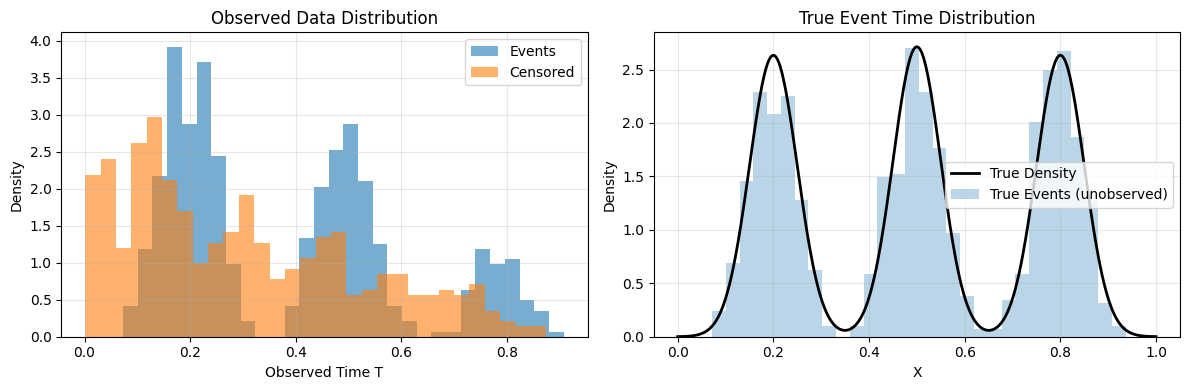

In [3]:
# Visualize data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Observed data histogram
axes[0].hist(data.loc[data['Delta'] == 1, 'T'], bins=30, alpha=0.6, label='Events', density=True)
axes[0].hist(data.loc[data['Delta'] == 0, 'T'], bins=30, alpha=0.6, label='Censored', density=True)
axes[0].set_xlabel('Observed Time T')
axes[0].set_ylabel('Density')
axes[0].set_title('Observed Data Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# True density
grid = np.linspace(0, 1, 500)
true_density = sampler.compute_density(grid)
axes[1].plot(grid, true_density, 'k-', linewidth=2, label='True Density')
axes[1].hist(X_true, bins=30, alpha=0.3, density=True, label='True Events (unobserved)')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Density')
axes[1].set_title('True Event Time Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 2. Kaplan-Meier Censoring Survival

Estimate the **censoring survival function** `S_c(t) = P(C > t)` using Kaplan-Meier.


KM estimated at 1000 unique time points
S_c(0.0) = 1.0000
S_c(0.5) = 0.5128
S_c(1.0) = 0.1056


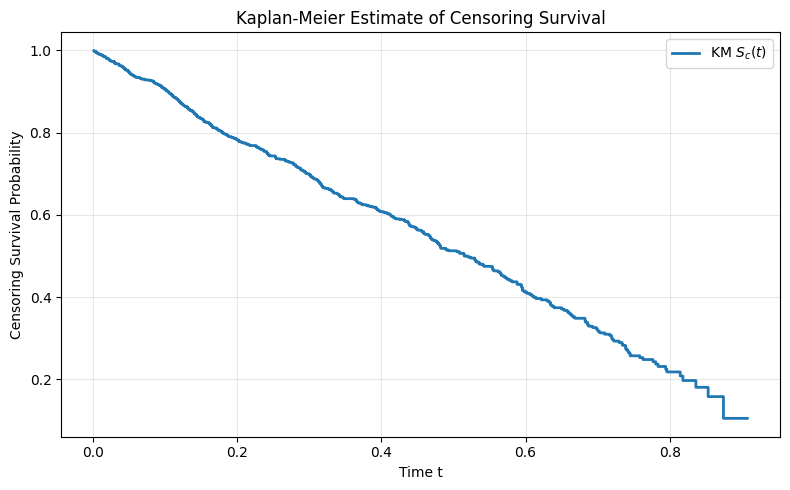

In [ ]:
# Fit Kaplan-Meier for censoring survival
km = KaplanMeier()
km.fit(data, time_col="T", delta_col="Delta")

# Get step function for plotting
km_times, km_surv = km.stepwise_survival_()

print(f"KM estimated at {len(km_times)} unique time points")
print(f"S_c(0.0) = {km.predict(0.0):.4f}")
print(f"S_c(0.5) = {km.predict(0.5):.4f}")
print(f"S_c(1.0) = {km.predict(1.0):.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.step(km_times, km_surv, where='post', linewidth=2, label='KM $S_c(t)$')
plt.xlabel('Time t')
plt.ylabel('Censoring Survival Probability')
plt.title('Kaplan-Meier Estimate of Censoring Survival')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Compute IPCW weights
T_vals = np.asarray(data["T"].values, dtype=float)
Delta_vals = np.asarray(data["Delta"].values, dtype=int)

def S_c_predict(t):
    """Predict censoring survival - returns np.ndarray."""
    return np.atleast_1d(km.predict(t))

ipcw_weights = compute_ipcw_weights(T=T_vals, Delta=Delta_vals, S_c_predict=S_c_predict)

print(f"IPCW weights: min={ipcw_weights.min():.4f}, max={ipcw_weights.max():.4f}, mean={ipcw_weights.mean():.4f}")
print(f"Non-zero weights (events): {(ipcw_weights > 0).sum()}")


IPCW weights: min=0.0000, max=9.4697, mean=1.0000
Non-zero weights (events): 514


## 3. IPCW-HAL Baseline (Manual Parameters)

Fit a **weighted HAL density estimator** using only uncensored observations with IPCW weights.

This uses manually chosen hyperparameters as a baseline.


In [ ]:
# Fit IPCW-weighted HAL estimator with manual parameters
uncensored_mask = Delta_vals == 1
ipcw_data = pd.DataFrame({"W1": T_vals[uncensored_mask]})
ipcw_weights_unc = ipcw_weights[uncensored_mask]

ipcw_baseline = RightCensoredIPCWEstimator(
    norm_constraint=200,
    basis_order=1,
    solver="ECOS",
)
ipcw_baseline.fit(ipcw_data, sample_weights=ipcw_weights_unc)

# Results
baseline_results = ipcw_baseline.get_results()
print(f"IPCW-HAL Baseline:")
print(f"  norm_constraint: 200")
print(f"  basis_order: 1")
print(f"  Knots selected: {len(baseline_results['grid_points_hal_selected'])}")

# Evaluate
eval_grid = np.linspace(0, 1, 500)
baseline_density = ipcw_baseline.get_density_at_points(eval_grid)
baseline_ll = incomplete_loglik(ipcw_baseline, data, time_col="T", delta_col="Delta")
baseline_kl = kl_divergence(
    true_pdf_fn=true_pdf_fn,
    grid=eval_grid,
    est_density=baseline_density,
)

print(f"\nPerformance:")
print(f"  Log-likelihood: {baseline_ll:.4f}")
print(f"  KL divergence: {baseline_kl:.4f}")


IPCW-HAL Baseline:
  norm_constraint: 200
  basis_order: 1
  Knots selected: 104

Performance:
  Log-likelihood: 24.8393
  KL divergence: 0.0595


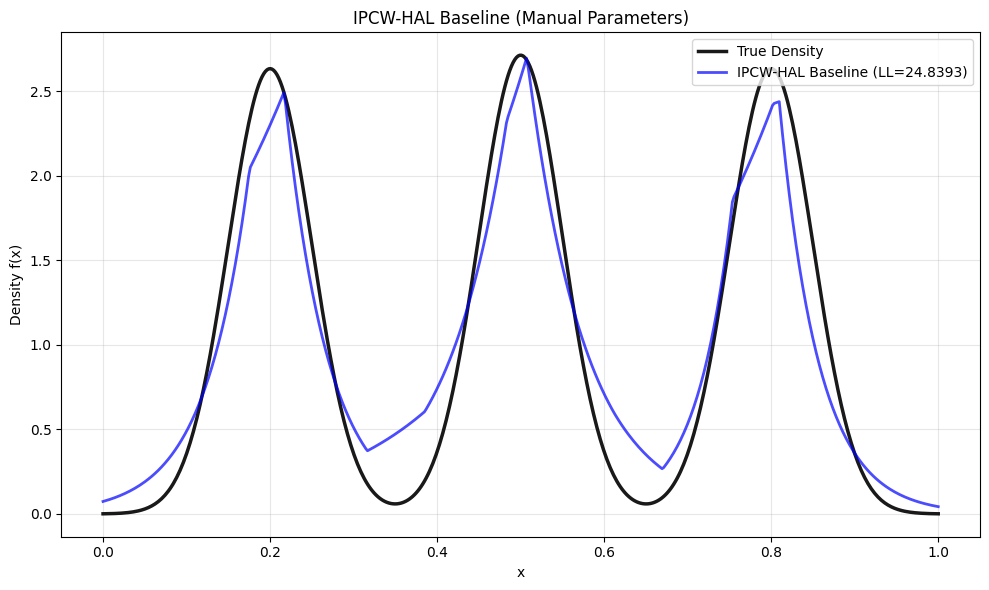

In [ ]:
# Plot baseline IPCW-HAL estimate
plt.figure(figsize=(10, 6))
plt.plot(grid, true_density, 'k-', linewidth=2.5, label='True Density', alpha=0.9)
plt.plot(eval_grid, baseline_density, 'b-', linewidth=2, label=f'IPCW-HAL Baseline (LL={baseline_ll:.4f})', alpha=0.7)
plt.xlabel('x')
plt.ylabel('Density f(x)')
plt.title('IPCW-HAL Baseline (Manual Parameters)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. CV-IPCW-HAL Tuning

Use **cross-validation** to optimize:
- `basis_order`: Order of HAL basis functions (0 or 1)
- `norm_constraint`: L1 norm constraint

The tuner maximizes incomplete log-likelihood on held-out folds.


In [ ]:
# CV-IPCW-HAL tuner
cv_tuner = RightCensoredOptunaHyperparameterTuner(
    estimator_name="RightCensoredIPCWEstimator",
    data=data,
    cv_folds=5,
    random_state=42,
    n_grid_points=200,
    param_overrides={
        "norm_constraint": {"low": 0.1, "high": 1000.0, "log": True},
        "basis_order": [0, 1],
    },
    silent=False,
)

print("Starting CV optimization...")
start_time = time.time()
cv_result = cv_tuner.optimize(n_trials=30)
optimization_time = time.time() - start_time

print(f"\n" + "="*50)
print(f"CV Optimization Complete")
print(f"="*50)
print(f"Time: {optimization_time:.2f}s")
print(f"Best params: {cv_result['best_params']}")
print(f"Best CV LL: {cv_result['best_metric_value']:.4f}")


Starting CV optimization...


Optuna CV:  30%|███       | 9/30 [00:10<00:25,  1.21s/trial, LL=-39.00, best=8.57, order=1]  /Users/houyilong/Documents/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
Optuna CV: 100%|██████████| 30/30 [00:34<00:00,  1.14s/trial, LL=-17.42, best=8.57, order=0]


CV Optimization Complete
Time: 34.33s
Best params: {'basis_order': 1, 'norm_constraint': 515.9267413494659}
Best CV LL: 8.5749


In [ ]:
# Fit best CV-IPCW-HAL model on full data
best_ipcw = cv_tuner.fit_best_model()

# Evaluate
cv_density = best_ipcw.get_density_at_points(eval_grid)
cv_ll = incomplete_loglik(best_ipcw, data, time_col="T", delta_col="Delta")
cv_kl = kl_divergence(
    true_pdf_fn=true_pdf_fn,
    grid=eval_grid,
    est_density=cv_density,
)

cv_results = best_ipcw.get_results()
print(f"CV-IPCW-HAL Best Model:")
print(f"  norm_constraint: {cv_result['best_params']['norm_constraint']:.4f}")
print(f"  basis_order: {cv_result['best_params']['basis_order']}")
print(f"  Knots selected: {len(cv_results['grid_points_hal_selected'])}")
print(f"\nPerformance:")
print(f"  Log-likelihood: {cv_ll:.4f}")
print(f"  KL divergence: {cv_kl:.4f}")


CV-IPCW-HAL Best Model:
  norm_constraint: 515.9267
  basis_order: 1
  Knots selected: 196

Performance:
  Log-likelihood: 66.5715
  KL divergence: 0.0165


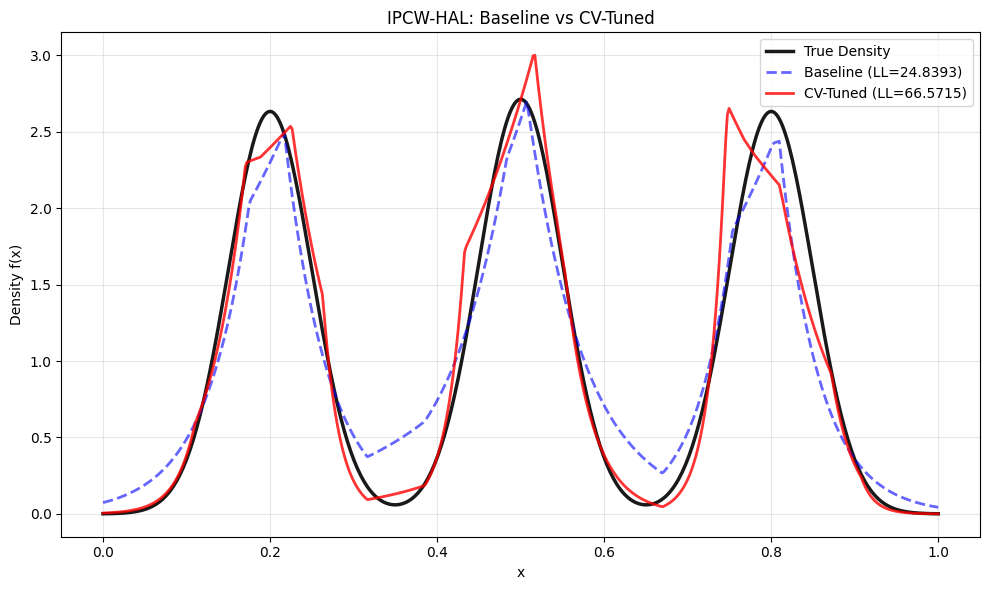

In [ ]:
# Plot: Baseline vs CV-tuned IPCW-HAL
plt.figure(figsize=(10, 6))
plt.plot(grid, true_density, 'k-', linewidth=2.5, label='True Density', alpha=0.9)
plt.plot(eval_grid, baseline_density, 'b--', linewidth=2, label=f'Baseline (LL={baseline_ll:.4f})', alpha=0.6)
plt.plot(eval_grid, cv_density, 'r-', linewidth=2, label=f'CV-Tuned (LL={cv_ll:.4f})', alpha=0.8)
plt.xlabel('x')
plt.ylabel('Density f(x)')
plt.title('IPCW-HAL: Baseline vs CV-Tuned')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Summary

Compare baseline (manual parameters) vs CV-tuned IPCW-HAL.


In [ ]:
# Summary table
print("=" * 60)
print("SUMMARY: CV-IPCW-HAL-MLE Results")
print("=" * 60)

results_summary = pd.DataFrame({
    "Method": [
        "IPCW-HAL Baseline (manual)",
        "CV-IPCW-HAL (tuned)",
    ],
    "norm_constraint": [
        200,
        cv_result['best_params']['norm_constraint'],
    ],
    "basis_order": [
        1,
        cv_result['best_params']['basis_order'],
    ],
    "Log-Likelihood": [baseline_ll, cv_ll],
    "KL Divergence": [baseline_kl, cv_kl],
})

print(results_summary.to_string(index=False))
print("=" * 60)

print(f"\nImprovement from CV tuning:")
print(f"  LL change: {cv_ll - baseline_ll:+.4f}")
print(f"  KL change: {cv_kl - baseline_kl:+.4f} (negative = better)")


SUMMARY: CV-IPCW-HAL-MLE Results
                    Method  norm_constraint  basis_order  Log-Likelihood  KL Divergence
IPCW-HAL Baseline (manual)       200.000000            1       24.839309       0.059509
       CV-IPCW-HAL (tuned)       515.926741            1       66.571527       0.016539

Improvement from CV tuning:
  LL change: +41.7322
  KL change: -0.0430 (negative = better)


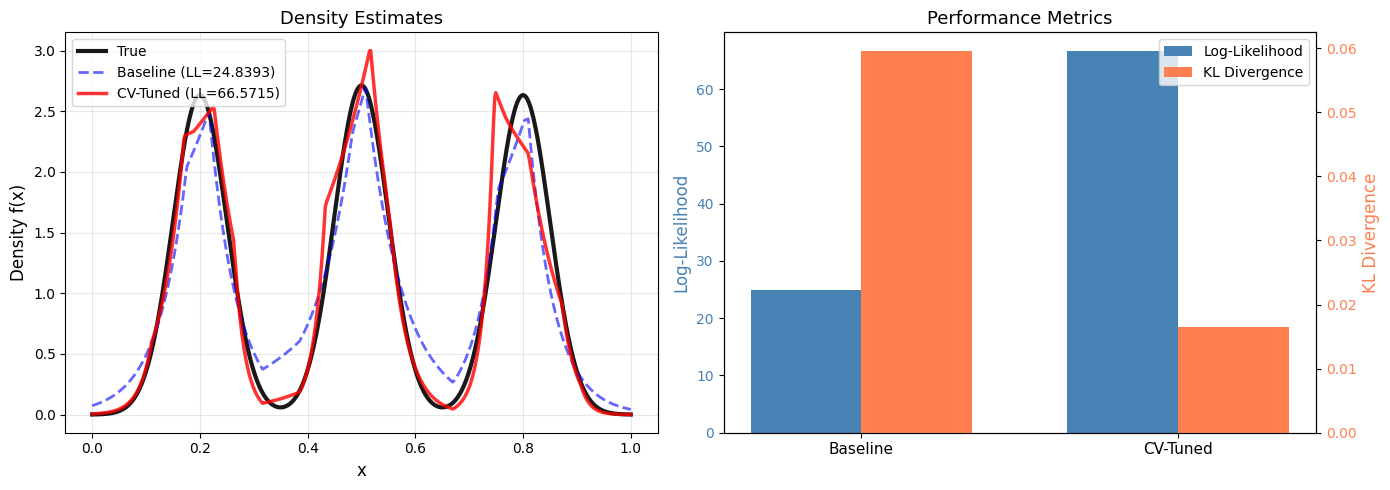

In [ ]:
# Final comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Density comparison
axes[0].plot(grid, true_density, 'k-', linewidth=3, label='True', alpha=0.9)
axes[0].plot(eval_grid, baseline_density, 'b--', linewidth=2, label=f'Baseline (LL={baseline_ll:.4f})', alpha=0.6)
axes[0].plot(eval_grid, cv_density, 'r-', linewidth=2.5, label=f'CV-Tuned (LL={cv_ll:.4f})', alpha=0.8)
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('Density f(x)', fontsize=12)
axes[0].set_title('Density Estimates', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Right: Metric comparison bar chart
methods = ['Baseline', 'CV-Tuned']
x = np.arange(len(methods))
width = 0.35

ax2 = axes[1]
bars1 = ax2.bar(x - width/2, [baseline_ll, cv_ll], width, label='Log-Likelihood', color='steelblue')
ax2.set_ylabel('Log-Likelihood', fontsize=12, color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax3 = ax2.twinx()
bars2 = ax3.bar(x + width/2, [baseline_kl, cv_kl], width, label='KL Divergence', color='coral')
ax3.set_ylabel('KL Divergence', fontsize=12, color='coral')
ax3.tick_params(axis='y', labelcolor='coral')

ax2.set_xticks(x)
ax2.set_xticklabels(methods, fontsize=11)
ax2.set_title('Performance Metrics', fontsize=13)

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()


## Key Takeaways

### CV-IPCW-HAL-MLE Workflow

1. Estimate censoring survival using Kaplan-Meier
2. Compute IPCW weights for uncensored observations
3. Tune hyperparameters using cross-validation
4. Fit final model on full data with best parameters

### When to Use CV-IPCW-HAL

- Fast baseline when EM refinement is not needed
- Moderate censoring where IPCW performs well
- Initial estimate for subsequent EM refinement
